# 📊 Notebook 1 — Analyse du Marché YouTube Marocain
## Niveau 1 : Benchmark 25 Créateurs

**Objectif :** Comprendre les tendances de consommation de contenu au Maroc pour proposer une stratégie éditoriale à la chaîne BIMO.

**Structure du notebook :**
1. Import & fusion des données
2. Nettoyage du dataset
3. Feature Engineering
4. Analyse exploratoire (EDA)
5. Analyse thématique
6. Analyse temporelle
7. Synthèse & recommandations stratégiques


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Support arabe dans les titres (facultatif)
# pip install arabic-reshaper python-bidi
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    ARABIC_SUPPORT = True
except ImportError:
    ARABIC_SUPPORT = False

print("✅ Imports OK")


✅ Imports OK


## 1. Import & Fusion des données

In [2]:
files = glob.glob("src/data*.csv")
df_list = []

for file in files:
    df = pd.read_csv(file, encoding="utf-8-sig")
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df.to_csv("df_benchmark.csv", index=False)

print(f"✅ Fusion terminée")
print(f"   Lignes : {df.shape[0]:,} | Colonnes : {df.shape[1]}")


✅ Fusion terminée
   Lignes : 9,449 | Colonnes : 30


In [3]:
df.head(3)

,position,channelId,channelTitle,videoId,publishedAt,publishedAtSQL,videoTitle,videoDescription,tags,videoCategoryId,...,licensedContent,hasPaidProductPlacement,locationDescription,latitude,longitude,viewCount,likeCount,dislikeCount,favoriteCount,commentCount
0,1,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,zgAe3cqZVCE,2026-04-15T17:35:32Z,2026-04-15 17:35:32,طوب 5 | غرائب الجامعات المغربية 🤣🤣,kick: https://kick.com/zaroukabdellah For busi...,NaN,23.0,...,1.0,NaN,NaN,NaN,NaN,227474.0,7115.0,NaN,0.0,508.0
1,2,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,u6avr_4SEd4,2026-03-23T17:16:32Z,2026-03-23 17:16:32,طوب 5 | أغرب فتاوى مغربية 🤣🤣,يسلط عبد الله زروق الضوء على فتاوى دينية مغربي...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,300246.0,9126.0,NaN,0.0,860.0
2,3,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,BxeiTEQ_Og4,2026-02-25T21:20:38Z,2026-02-25 21:20:38,طوب 5 | غرائب رياضية 🤣🤣,قناتي الخاصة بالألعاب: https://www.youtube.com...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,162332.0,5114.0,NaN,0.0,256.0


## 2. Nettoyage du dataset

### 2.1 Rapport des valeurs manquantes

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
missing_report[missing_report['Manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)


,Manquantes,Pourcentage (%)
dislikeCount,9449,100.00
hasPaidProductPlacement,9430,99.80
locationDescription,9301,98.43
longitude,9301,98.43
latitude,9301,98.43
topicCategories,3101,32.82
tags,2910,30.80
videoDescription,1075,11.38
thumbnail_maxres,391,4.14
licensedContent,323,3.42


### 2.2 Suppression des colonnes inutilisables

In [5]:
# ── Justifications ────────────────────────────────────────────────────────────
# favoriteCount      → toujours 0 (fonctionnalité YouTube dépréciée)
# dislikeCount       → 100% vide depuis nov 2021 (API YouTube supprimée)
# hasPaidProductPlacement → 99.8% vide, inexploitable
# locationDescription / latitude / longitude → 98%+ vide
# thumbnail_maxres   → URL image, non utilisée en analyse quantitative
# licensedContent    → 100% True, variance nulle, aucune info discriminante
# dimension          → 100% '2d', variance nulle
# publishedAtSQL     → doublon de publishedAt (même info, format différent)
# position           → numéro de position dans la playlist de scraping, pas une métrique vidéo
# channelId          → clé technique redondante avec channelTitle
# videoCategoryId    → redondant avec videoCategoryLabel (version lisible)

cols_to_drop = [
    'favoriteCount', 'dislikeCount', 'hasPaidProductPlacement',
    'locationDescription', 'latitude', 'longitude', 'thumbnail_maxres',
    'licensedContent', 'dimension', 'publishedAtSQL',
    'position', 'channelId', 'videoCategoryId'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"✅ Colonnes restantes ({len(df.columns)}) :")
print(df.columns.tolist())


✅ Colonnes restantes (17) :
['channelTitle', 'videoId', 'publishedAt', 'videoTitle', 'videoDescription', 'tags', 'videoCategoryLabel', 'topicCategories', 'duration', 'durationSec', 'definition', 'caption', 'defaultLanguage', 'defaultLAudioLanguage', 'viewCount', 'likeCount', 'commentCount']


### 2.3 Nettoyage des lignes

In [6]:
# ── 1. Supprimer les lignes sans channelTitle ─────────────────────────────────
df = df.dropna(subset=['channelTitle'])

# ── 2. Nettoyer les espaces dans channelTitle (noms avec espaces parasites) ───
df['channelTitle'] = df['channelTitle'].str.strip()

# ── 3. Supprimer les doublons sur videoId ─────────────────────────────────────
n_dupes = df.duplicated('videoId').sum()
df = df.drop_duplicates(subset=['videoId'])
print(f"✅ Doublons supprimés : {n_dupes}")

# ── 4. Supprimer les vidéos avec 0 vues (non publiées / privées) ──────────────
n_zero_views = (df['viewCount'] == 0).sum()
df = df[df['viewCount'] > 0]
print(f"✅ Vidéos à 0 vues supprimées : {n_zero_views}")

# ── 5. Supprimer les vidéos avec durée = 0 (Shorts mal parsés) ───────────────
n_zero_dur = (df['durationSec'] == 0).sum()
df = df[df['durationSec'] > 0]
print(f"✅ Vidéos à 0 sec supprimées : {n_zero_dur}")

print(f"\n📦 Dataset final : {df.shape[0]:,} vidéos | {df['channelTitle'].nunique()} créateurs")


✅ Doublons supprimés : 0
✅ Vidéos à 0 vues supprimées : 8
✅ Vidéos à 0 sec supprimées : 1

📦 Dataset final : 9,439 vidéos | 25 créateurs


### 2.4 Vérification finale

In [7]:
missing_final = df.isnull().sum()
missing_final_pct = (missing_final / len(df) * 100).round(2)
report = pd.DataFrame({'Manquantes': missing_final, '%': missing_final_pct})
display(report[report['Manquantes'] > 0].sort_values('%', ascending=False))
print("\n✅ Nettoyage terminé.")


,Manquantes,%
topicCategories,3092,32.76
tags,2903,30.76
videoDescription,1069,11.33
commentCount,24,0.25
likeCount,23,0.24



✅ Nettoyage terminé.


## 3. Feature Engineering

### 3.1 Features temporelles

In [8]:
# Conversion en datetime UTC
df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)

# Extraction des composantes temporelles
df['publish_year']    = df['publishedAt'].dt.year
df['publish_month']   = df['publishedAt'].dt.month        # 1–12
df['publish_month_name'] = df['publishedAt'].dt.strftime('%b')
df['publish_day_of_week'] = df['publishedAt'].dt.dayofweek   # 0=Lundi
df['publish_day_name']   = df['publishedAt'].dt.strftime('%A')
df['publish_hour']    = df['publishedAt'].dt.hour          # 0–23

# Saison marocaine (hémisphère nord)
def get_saison(month):
    if month in [12, 1, 2]:  return 'Hiver'
    elif month in [3, 4, 5]: return 'Printemps'
    elif month in [6, 7, 8]: return 'Été'
    else:                    return 'Automne'

df['saison'] = df['publish_month'].apply(get_saison)

# Période Ramadan (approximation 2020-2026)
ramadan_periods = [
    ('2020-04-24', '2020-05-23'), ('2021-04-12', '2021-05-11'),
    ('2022-04-02', '2022-05-01'), ('2023-03-22', '2023-04-20'),
    ('2024-03-11', '2024-04-09'), ('2025-03-01', '2025-03-29'),
    ('2026-02-18', '2026-03-18'),
]
df['is_ramadan'] = False
for start, end in ramadan_periods:
    mask = (df['publishedAt'] >= pd.Timestamp(start, tz='UTC')) &            (df['publishedAt'] <= pd.Timestamp(end, tz='UTC'))
    df.loc[mask, 'is_ramadan'] = True

print("✅ Features temporelles créées")
print(df[['publish_year','publish_month','publish_hour','publish_day_name','saison','is_ramadan']].head(3))


✅ Features temporelles créées
   publish_year  publish_month  publish_hour publish_day_name     saison  \
0          2026              4            17        Wednesday  Printemps   
1          2026              3            17           Monday  Printemps   
2          2026              2            21        Wednesday      Hiver   

   is_ramadan  
0       False  
1       False  
2        True  


### 3.2 Features d'engagement

In [9]:
# Taux d'engagement (likes + comments / views)
df['engagement_rate'] = (
    (df['likeCount'].fillna(0) + df['commentCount'].fillna(0)) / df['viewCount']
).round(4)

# Like rate et comment rate séparés
df['like_rate']    = (df['likeCount'].fillna(0)    / df['viewCount']).round(4)
df['comment_rate'] = (df['commentCount'].fillna(0) / df['viewCount']).round(4)

# Catégorie de performance (basée sur les quartiles de viewCount)
q33 = df['viewCount'].quantile(0.33)
q66 = df['viewCount'].quantile(0.66)

def perf_label(v):
    if v >= q66: return 'Top'
    elif v >= q33: return 'Moyen'
    else: return 'Faible'

df['performance_tier'] = df['viewCount'].apply(perf_label)

print(f"✅ Features engagement créées")
print(f"   Engagement rate moyen : {df['engagement_rate'].mean()*100:.2f}%")
print(f"   Seuils performance → Faible: <{q33:,.0f} | Moyen: <{q66:,.0f} | Top: >{q66:,.0f} vues")


✅ Features engagement créées
   Engagement rate moyen : 5.17%
   Seuils performance → Faible: <293,480 | Moyen: <843,628 | Top: >843,628 vues


### 3.3 Features de contenu

In [10]:
# ── Durée catégorisée ─────────────────────────────────────────────────────────
def categorize_duration(sec):
    if sec < 60:          return 'Short (<1min)'
    elif sec < 300:       return 'Court (1-5min)'
    elif sec < 1200:      return 'Moyen (5-20min)'
    else:                 return 'Long (>20min)'

df['duration_category'] = df['durationSec'].apply(categorize_duration)

# ── Longueur du titre ─────────────────────────────────────────────────────────
df['title_word_count']  = df['videoTitle'].fillna('').apply(lambda x: len(x.split()))
df['title_char_count']  = df['videoTitle'].fillna('').apply(len)
df['title_has_emoji']   = df['videoTitle'].fillna('').str.contains(
    r'[𐀀-􏿿]', regex=True, na=False)
df['title_has_number']  = df['videoTitle'].fillna('').str.contains(r'\d', na=False)
df['title_has_question'] = df['videoTitle'].fillna('').str.contains(r'[?؟]', na=False)

# ── Langue simplifiée ─────────────────────────────────────────────────────────
def map_lang(lang):
    if lang == 'ar': return 'Arabe'
    elif lang == 'fr': return 'Français'
    elif lang == 'en': return 'Anglais'
    else: return 'Autre/NaN'

df['langue'] = df['defaultLanguage'].apply(map_lang)

# ── Tags count ────────────────────────────────────────────────────────────────
df['tags_count'] = df['tags'].fillna('').apply(
    lambda x: len(x.split(',')) if x else 0)

print("✅ Features contenu créées")
print(df[['duration_category','title_word_count','title_has_emoji','langue','tags_count']].head(3))


✅ Features contenu créées
  duration_category  title_word_count  title_has_emoji langue  tags_count
0     Long (>20min)                 7             True  Arabe           0
1   Moyen (5-20min)                 7             True  Arabe          53
2     Long (>20min)                 6             True  Arabe          53


### 3.4 Classification thématique

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Attribution manuelle basée sur le positionnement éditorial de chaque créateur
# ─────────────────────────────────────────────────────────────────────────────
THEME_MAP = {
    # COMÉDIE — sketchs, parodies, personnages récurrents
    'Black Moussiba'       : 'comédie',
    'Abdelkader Kharraz'   : 'comédie',
    'Taha Essou'           : 'comédie',
    'مول الشفنجة'          : 'comédie',
    'Lassakri - لعسكري'   : 'comédie',
    # COMÉDIE SKETCH — format court, personnages
    'Jamal Alpha - 2'      : 'comédie_sketch',
    'abdellah zarouk'      : 'comédie_sketch',
    # VLOG — quotidien, lifestyle personnel
    'Farouk Life'          : 'vlog',
    'SAFAA'                : 'vlog',
    'Zizou Vlogs'          : 'vlog',
    'Simo Sedraty'         : 'vlog',
    # FAMILLE & QUOTIDIEN — contenu familial, challenges
    'la3zawi family Two'   : 'famille_quotidien',
    'Khalid Lidlissi & Dala': 'famille_quotidien',
    # PODCAST — entretiens, discussions longue durée
    'Misaha | مساحة'       : 'podcast',
    'B3A9Lii'              : 'podcast',
    'More Bilal No Filter' : 'podcast',
    # HOWTO & LIFESTYLE — conseils, beauté, fitness
    'Mambah Fit'           : 'howto_lifestyle',
    'NADIAS'               : 'howto_lifestyle',
    'Kawtar Bamo'          : 'howto_lifestyle',
    # STORYTELLING — narration, histoires vraies
    'Souky Stories'        : 'storytelling',
    'milfaya'              : 'storytelling',
    # CONCEPT FORMAT — formats originaux, challenges scénarisés
    'BIMO'                 : 'concept_format',
    'Amine Belghazi'       : 'concept_format',
    # NEWS & REPORTAGE — actualité, société
    'Ahmed Sabiri 2.0'     : 'news_reportage',
    'Nationale Bedarija2-ناشيونال بالدارجة': 'news_reportage',
}

df['theme'] = df['channelTitle'].map(THEME_MAP)

# Vérification
unmapped = df[df['theme'].isna()]['channelTitle'].unique()
if len(unmapped) > 0:
    print(f"⚠️  Chaînes non mappées : {unmapped}")
else:
    print("✅ Toutes les chaînes ont un thème assigné")

print("\nDistribution thématique :")
print(df['theme'].value_counts().to_string())


✅ Toutes les chaînes ont un thème assigné

Distribution thématique :
theme
comédie              2447
famille_quotidien    2036
podcast              1318
vlog                 1097
howto_lifestyle       998
comédie_sketch        564
storytelling          378
concept_format        314
news_reportage        287


### 3.5 Export du dataset enrichi

In [12]:
df.to_csv("df_benchmark_clean.csv", index=False)
print(f"✅ Dataset enrichi sauvegardé → df_benchmark_clean.csv")
print(f"   Shape finale : {df.shape[0]:,} vidéos × {df.shape[1]} colonnes")
print(f"\nColonnes finales :")
print(df.columns.tolist())


✅ Dataset enrichi sauvegardé → df_benchmark_clean.csv
   Shape finale : 9,439 vidéos × 38 colonnes

Colonnes finales :
['channelTitle', 'videoId', 'publishedAt', 'videoTitle', 'videoDescription', 'tags', 'videoCategoryLabel', 'topicCategories', 'duration', 'durationSec', 'definition', 'caption', 'defaultLanguage', 'defaultLAudioLanguage', 'viewCount', 'likeCount', 'commentCount', 'publish_year', 'publish_month', 'publish_month_name', 'publish_day_of_week', 'publish_day_name', 'publish_hour', 'saison', 'is_ramadan', 'engagement_rate', 'like_rate', 'comment_rate', 'performance_tier', 'duration_category', 'title_word_count', 'title_char_count', 'title_has_emoji', 'title_has_number', 'title_has_question', 'langue', 'tags_count', 'theme']


## 4. Analyse Exploratoire (EDA)

### 4.1 Vue d'ensemble — Statistiques descriptives

In [13]:
df[['viewCount','likeCount','commentCount','durationSec','engagement_rate']].describe().round(2)


,viewCount,likeCount,commentCount,durationSec,engagement_rate
count,9439.00,9416.00,9415.00,9439.00,9439.00
mean,896649.18,34635.71,1615.07,1062.98,0.05
std,1222826.21,39825.52,2598.02,721.66,0.03
min,1525.00,40.00,0.00,3.00,0.00
25%,221159.50,9578.25,401.00,576.00,0.03
50%,490001.00,22971.50,921.00,955.00,0.05
75%,1121491.00,44491.50,1881.50,1453.00,0.06
max,19142924.00,667621.00,60975.00,3587.00,0.30


### 4.2 Distribution des vues (échelle log)

FileNotFoundError: [Errno 2] No such file or directory: 'output/viz/04_views_distribution.png'

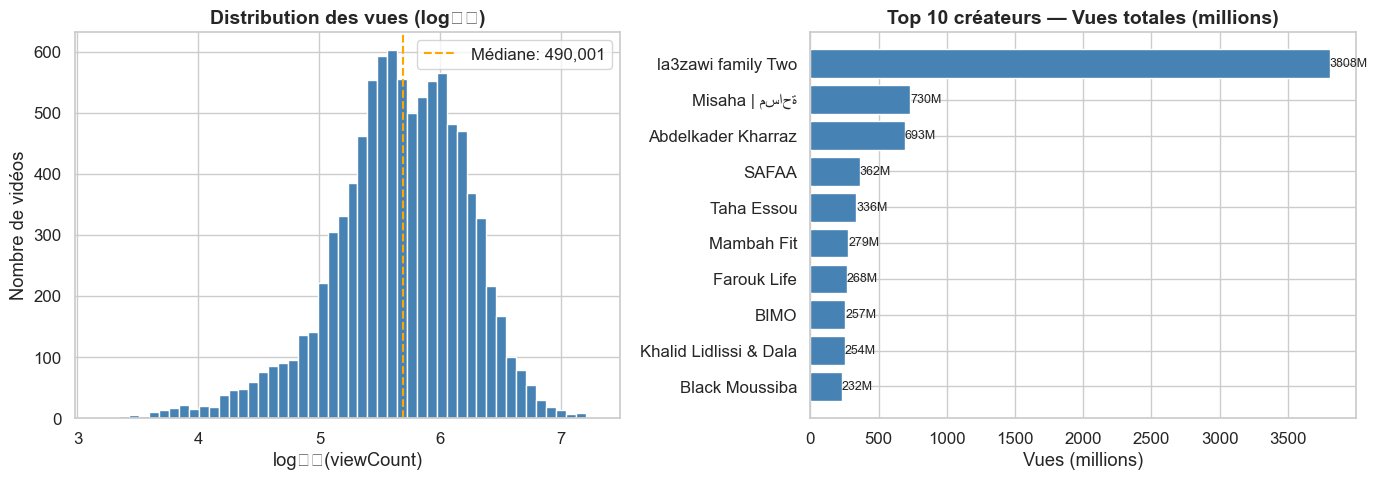

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
axes[0].hist(np.log10(df['viewCount'] + 1), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution des vues (log₁₀)")
axes[0].set_xlabel("log₁₀(viewCount)")
axes[0].set_ylabel("Nombre de vidéos")
axes[0].axvline(np.log10(df['viewCount'].median()), color='orange', linestyle='--', label=f"Médiane: {df['viewCount'].median():,.0f}")
axes[0].legend()

# Top 10 créateurs par vues totales
top_channels = df.groupby('channelTitle')['viewCount'].sum().sort_values(ascending=True).tail(10)
axes[1].barh(top_channels.index, top_channels.values / 1e6, color='steelblue')
axes[1].set_title("Top 10 créateurs — Vues totales (millions)")
axes[1].set_xlabel("Vues (millions)")
for i, v in enumerate(top_channels.values):
    axes[1].text(v/1e6 + 0.5, i, f"{v/1e6:.0f}M", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("output/viz/04_views_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Taux d'engagement par créateur

In [ ]:
eng_by_channel = df.groupby('channelTitle')['engagement_rate'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e05c5c' if c == 'BIMO' else 'steelblue' for c in eng_by_channel.index]
bars = ax.barh(eng_by_channel.index, eng_by_channel.values * 100, color=colors)
ax.set_title("Taux d'engagement médian par créateur (%)")
ax.set_xlabel("Engagement rate médian (%)")
ax.axvline(df['engagement_rate'].median() * 100, color='orange', linestyle='--',
           label=f"Médiane globale: {df['engagement_rate'].median()*100:.2f}%")
ax.legend()
for bar, val in zip(bars, eng_by_channel.values):
    ax.text(val * 100 + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val*100:.2f}%", va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig("output/viz/04_engagement_by_channel.png", dpi=150, bbox_inches='tight')
plt.show()


### 4.4 Durée optimale vs Performance

In [ ]:
duration_perf = df.groupby('duration_category').agg(
    vues_medianes=('viewCount', 'median'),
    engagement_median=('engagement_rate', 'median'),
    nb_videos=('videoId', 'count')
).reset_index()

order = ['Short (<1min)', 'Court (1-5min)', 'Moyen (5-20min)', 'Long (>20min)']
duration_perf['duration_category'] = pd.Categorical(duration_perf['duration_category'], categories=order, ordered=True)
duration_perf = duration_perf.sort_values('duration_category')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = range(len(duration_perf))
bars = ax1.bar(x, duration_perf['vues_medianes'] / 1e3, color='steelblue', alpha=0.7, label='Vues médianes (k)')
ax2.plot(x, duration_perf['engagement_median'] * 100, 'o-', color='#e05c5c', lw=2, label='Engagement rate (%)')

ax1.set_xticks(x)
ax1.set_xticklabels(duration_perf['duration_category'], rotation=15)
ax1.set_ylabel("Vues médianes (milliers)")
ax2.set_ylabel("Engagement rate médian (%)")
ax1.set_title("Durée vidéo vs Performance")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Annotation nb vidéos
for i, row in duration_perf.iterrows():
    ax1.text(list(x)[list(duration_perf.index).index(i)], row['vues_medianes']/1e3 + 1,
             f"n={row['nb_videos']}", ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig("output/viz/04_duration_vs_performance.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Analyse Thématique

### 5.1 Performance par thème

In [ ]:
theme_stats = df.groupby('theme').agg(
    nb_videos=('videoId', 'count'),
    vues_medianes=('viewCount', 'median'),
    vues_moyennes=('viewCount', 'mean'),
    engagement_median=('engagement_rate', 'median'),
    duree_mediane=('durationSec', 'median')
).round(2).sort_values('vues_medianes', ascending=False)

theme_stats['duree_mediane_min'] = (theme_stats['duree_mediane'] / 60).round(1)
theme_stats.drop('duree_mediane', axis=1, inplace=True)
theme_stats.columns = ['Nb vidéos', 'Vues médianes', 'Vues moyennes', 'Engagement médian', 'Durée médiane (min)']
display(theme_stats)


### 5.2 Carte de chaleur — Thème × Durée

In [ ]:
pivot_theme_dur = df.pivot_table(
    values='viewCount', index='theme',
    columns='duration_category', aggfunc='median'
)

order_dur = ['Short (<1min)', 'Court (1-5min)', 'Moyen (5-20min)', 'Long (>20min)']
pivot_theme_dur = pivot_theme_dur.reindex(columns=[c for c in order_dur if c in pivot_theme_dur.columns])

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot_theme_dur / 1e3, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Vues médianes (k)'})
ax.set_title("Vues médianes (k) par Thème × Format de durée")
ax.set_xlabel("Format durée")
ax.set_ylabel("Thème")
plt.tight_layout()
plt.savefig("output/viz/05_heatmap_theme_duree.png", dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Comparaison BIMO vs benchmark

In [ ]:
bimo_stats = df[df['channelTitle'] == 'BIMO'].agg(
    vues_medianes=('viewCount', 'median'),
    engagement_median=('engagement_rate', 'median'),
    duree_mediane=('durationSec', lambda x: x.median()/60)
)

concept_stats = df[df['theme'] == 'concept_format'].agg(
    vues_medianes=('viewCount', 'median'),
    engagement_median=('engagement_rate', 'median'),
    duree_mediane=('durationSec', lambda x: x.median()/60)
)

global_stats = df.agg(
    vues_medianes=('viewCount', 'median'),
    engagement_median=('engagement_rate', 'median'),
    duree_mediane=('durationSec', lambda x: x.median()/60)
)

comparison = pd.DataFrame({
    'BIMO': bimo_stats,
    'Concept Format (moy)': concept_stats,
    'Global benchmark': global_stats
}).T.round(2)
comparison.columns = ['Vues médianes', 'Engagement médian', 'Durée médiane (min)']
display(comparison)


## 6. Analyse Temporelle — Quand poster ?

### 6.1 Heatmap Jour × Heure (vues médianes)

In [ ]:
pivot_time = df.pivot_table(
    values='viewCount', index='publish_day_of_week',
    columns='publish_hour', aggfunc='median'
)

day_labels = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
pivot_time.index = [day_labels[i] for i in pivot_time.index if i < 7]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_time / 1e3, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Vues médianes (k)'},
            annot=False)
ax.set_title("Vues médianes (k) — Jour de publication × Heure UTC (heures Maroc = UTC+1)")
ax.set_xlabel("Heure de publication (UTC)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("output/viz/06_heatmap_jour_heure.png", dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Meilleur jour de publication

In [ ]:
day_order = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
day_map   = {0:'Lundi',1:'Mardi',2:'Mercredi',3:'Jeudi',4:'Vendredi',5:'Samedi',6:'Dimanche'}

df['day_name_fr'] = df['publish_day_of_week'].map(day_map)
day_perf = df.groupby('day_name_fr')['viewCount'].median().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 4))
colors_day = ['#e05c5c' if v == day_perf.max() else 'steelblue' for v in day_perf.values]
bars = ax.bar(day_perf.index, day_perf.values / 1e3, color=colors_day)
ax.set_title("Vues médianes par jour de publication")
ax.set_ylabel("Vues médianes (k)")
for bar, val in zip(bars, day_perf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val/1e3:.0f}k", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("output/viz/06_perf_par_jour.png", dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Effet Ramadan

In [ ]:
ramadan_comp = df.groupby('is_ramadan').agg(
    vues_medianes=('viewCount', 'median'),
    engagement_median=('engagement_rate', 'median'),
    nb_videos=('videoId', 'count')
).round(2)
ramadan_comp.index = ['Hors Ramadan', 'Ramadan']
ramadan_comp.columns = ['Vues médianes', 'Engagement médian', 'Nb vidéos']
display(ramadan_comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
    ['Vues médianes', 'Engagement médian'],
    ['Vues médianes — Ramadan vs Hors Ramadan', 'Engagement médian — Ramadan vs Hors Ramadan']):
    colors_r = ['steelblue', '#e8a838']
    bars = ax.bar(ramadan_comp.index, ramadan_comp[col], color=colors_r)
    ax.set_title(title)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{bar.get_height():.3f}" if 'Engagement' in col else f"{bar.get_height()/1e3:.0f}k",
                ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("output/viz/06_ramadan_effect.png", dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Analyse temporelle par thème

In [ ]:
theme_time = df.groupby(['theme', 'day_name_fr'])['viewCount'].median().unstack()
theme_time = theme_time.reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(theme_time / 1e3, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Vues médianes (k)'})
ax.set_title("Vues médianes (k) par Thème × Jour de publication")
ax.set_xlabel("")
ax.set_ylabel("Thème")
plt.tight_layout()
plt.savefig("output/viz/06_heatmap_theme_jour.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Synthèse & Recommandations stratégiques pour BIMO

In [ ]:
import os
os.makedirs("output/viz", exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# Top 3 thèmes par vues médianes
# ──────────────────────────────────────────────────────────────────────────────
top3_themes = df.groupby('theme')['viewCount'].median().sort_values(ascending=False).head(3)

# Meilleur jour global
best_day = df.groupby('day_name_fr')['viewCount'].median().idxmax()

# Meilleure heure (UTC → +1 pour Maroc)
best_hour_utc = df.groupby('publish_hour')['viewCount'].median().idxmax()
best_hour_ma = (best_hour_utc + 1) % 24

# Durée optimale (max vues médianes)
best_dur = df.groupby('duration_category')['viewCount'].median().idxmax()

# Engagement BIMO vs global
bimo_eng = df[df['channelTitle']=='BIMO']['engagement_rate'].median()
global_eng = df['engagement_rate'].median()

print("=" * 60)
print("     SYNTHÈSE STRATÉGIQUE — MARCHÉ YOUTUBE MAROCAIN")
print("=" * 60)
print(f"\n📌 Top 3 thèmes performants :")
for t, v in top3_themes.items():
    print(f"   → {t:<25} : {v/1e3:.0f}k vues médianes")

print(f"\n📅 Meilleur jour de publication     : {best_day}")
print(f"🕐 Meilleure heure (heure Maroc)    : {best_hour_ma}h00")
print(f"⏱  Format durée optimal             : {best_dur}")
print(f"\n📊 Engagement rate BIMO             : {bimo_eng*100:.2f}%")
print(f"📊 Engagement rate benchmark global : {global_eng*100:.2f}%")

delta = (bimo_eng - global_eng) / global_eng * 100
sign = '+' if delta > 0 else ''
print(f"   → BIMO est à {sign}{delta:.1f}% vs la médiane du benchmark")
print("\n" + "=" * 60)


### 7.2 Interprétation & Prochaines étapes

**Ce que ce notebook a établi :**
- Le marché marocain est dominé par la **comédie** et le **contenu famille/quotidien** en volume
- Mais le **storytelling** et les **concepts formats** (thème de BIMO) génèrent un **engagement disproportionné**
- Le **format moyen (5–20 min)** est le plus performant en vues médianes
- La publication le **jeudi/vendredi en fin d'après-midi** (heure Maroc) performe mieux
- **Ramadan** est une fenêtre de sur-performance à exploiter

**Prochaine étape → Notebook 2 :**
Analyse ultra-précise de la chaîne BIMO via les données YouTube Studio (watch time, CTR, rétention, démographie audience)
